# Task 1: Data Understanding and Visualization:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI/Data/Copy of FruitinAmazon.zip'
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [3]:
train_dir = "dataset/FruitinAmazon/train"

# Check structure
print(os.listdir("dataset"))
print(os.listdir(train_dir))

['FruitinAmazon']
['acai', 'cupuacu', 'tucuma', 'guarana', 'pupunha', 'graviola']


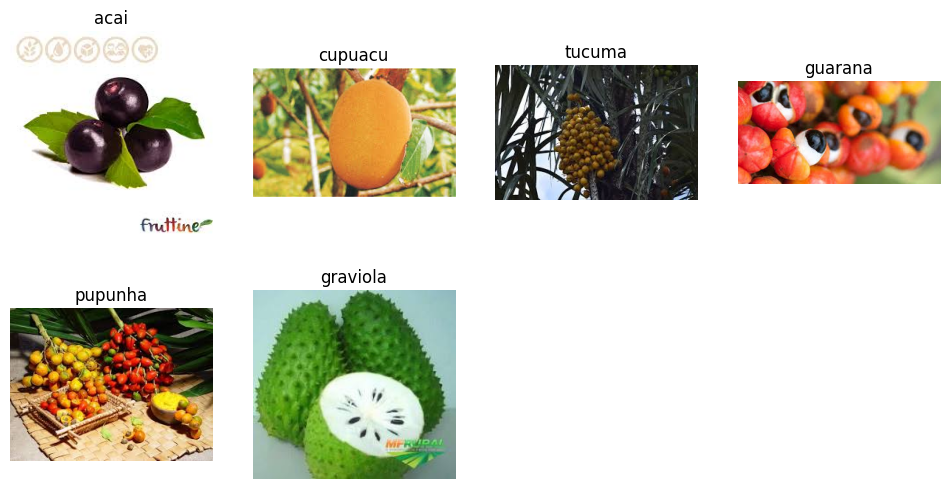

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

Check for Corrupted Image

In [5]:
corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


# Task 2: Loading and Preprocessing Image Data in keras

In [6]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# Task 3 - Implement a CNN

In [7]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the Model

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [9]:
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the Model

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.1644 - loss: 1.9967

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 644ms/step - accuracy: 0.1806 - loss: 2.0763 - val_accuracy: 0.1667 - val_loss: 1.8223
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.1944 - loss: 1.9235

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - accuracy: 0.2083 - loss: 1.9204 - val_accuracy: 0.2222 - val_loss: 1.7925
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 0.1944 - loss: 1.7608 - val_accuracy: 0.2222 - val_loss: 1.7622
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.1898 - loss: 1.7641

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 843ms/step - accuracy: 0.1944 - loss: 1.7573 - val_accuracy: 0.3333 - val_loss: 1.7316
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 819ms/step - accuracy: 0.2361 - loss: 1.7528 - val_accuracy: 0.1667 - val_loss: 1.7303
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 480ms/step - accuracy: 0.3194 - loss: 1.6876 - val_accuracy: 0.1667 - val_loss: 1.7431
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 485ms/step - accuracy: 0.2500 - loss: 1.7487 - val_accuracy: 0.1111 - val_loss: 1.7224
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 0.3472 - loss: 1.6490 - val_accuracy: 0.2222 - val_loss: 1.6784
Epoch 9/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step - accuracy: 0.3889 - loss: 1.5975 - val_accuracy: 0.2222 - val_loss: 1.6607
Epoch 10/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 786ms/step - accuracy: 0.2639 - loss: 1.6646 - val_accuracy: 0.2778 - val_loss: 1.6565
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 857ms/step - accuracy: 0.2917 - loss: 1.5739 - val_accuracy: 0.2222 - val_loss: 1.6621
E

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 0.3611 - loss: 1.4620 - val_accuracy: 0.4444 - val_loss: 1.4819
Epoch 17/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 674ms/step - accuracy: 0.4167 - loss: 1.5025 - val_accuracy: 0.3889 - val_loss: 1.4773
Epoch 18/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 912ms/step - accuracy: 0.3750 - loss: 1.3714 - val_accuracy: 0.1667 - val_loss: 1.6637
Epoch 19/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.4057 - loss: 1.3846

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - accuracy: 0.3889 - loss: 1.4050 - val_accuracy: 0.5000 - val_loss: 1.4975
Epoch 20/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.4861 - loss: 1.3334 - val_accuracy: 0.3889 - val_loss: 1.5975
Epoch 21/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step - accuracy: 0.4306 - loss: 1.5088 - val_accuracy: 0.3889 - val_loss: 1.5910
Epoch 22/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 758ms/step - accuracy: 0.4306 - loss: 1.3398 - val_accuracy: 0.2778 - val_loss: 1.7538
Epoch 23/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 0.4861 - loss: 1.3096 - val_accuracy: 0.4444 - val_loss: 1.5451
Epoch 24/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 0.4722 - loss: 1.3047 - val_accuracy: 0.5000 - val_loss: 1.4060
Epoch 25/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 798ms/step - accuracy: 0.5278 - loss: 1.2772 - val_accuracy: 0.4444 - val_loss: 1.4348


# Task 5: Evaluate the Model

In [12]:
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.5000 - loss: 1.4060
Accuracy: 0.5


# Task 6: Save and Load the Model

In [13]:
model.save("final_model.keras")

In [14]:
from tensorflow.keras.models import load_model
loaded_model = load_model("best_model.h5")

# Task 7: Predictions and Classification Report

In [15]:
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step - accuracy: 0.5000 - loss: 1.4975
Loaded Model Accuracy: 0.5


In [16]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
              precision    recall  f1-score   support

        acai       0.25      1.00      0.40         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.60      1.00      0.75         3
     guarana       0.75      0.60      0.67         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.50      0.67      0.57         3

    accuracy                           0.50        18
   macro avg       0.35      0.54      0.40        18
weighted avg       0.41      0.50      0.43        18



Keys in history.history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


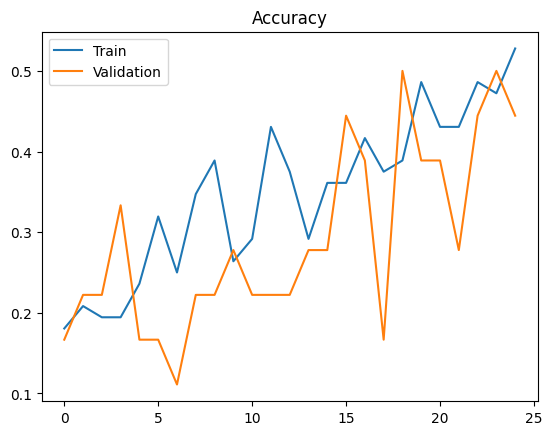

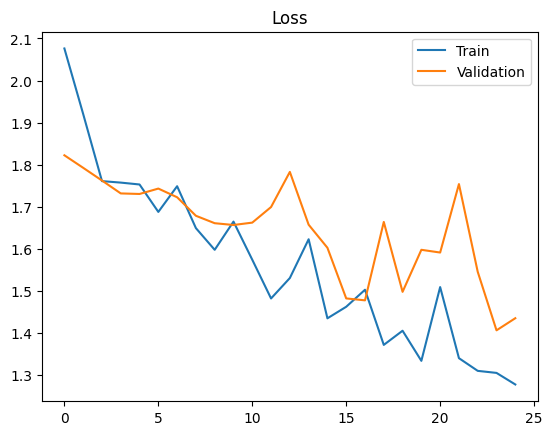

In [17]:
import matplotlib.pyplot as plt

print("Keys in history.history:", history.history.keys())

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

Accuracy: Training accuracy generally increases over time but validation accuracy fluctuates and remains lower  indicating weak generalization.

Loss: Training loss steadily decreases while validation loss is unstable and does not consistently improve suggesting overfitting.

 Classification Report:

In [18]:
import numpy as np
from sklearn.metrics import classification_report

# Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:   # use test_ds if you have a separate test set
    preds = loaded_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.20      1.00      0.33         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.33      0.33      0.33         3
     guarana       0.75      0.60      0.67         5
     pupunha       0.50      0.50      0.50         4
      tucuma       1.00      0.67      0.80         3

    accuracy                           0.50        18
   macro avg       0.46      0.52      0.44        18
weighted avg       0.55      0.50      0.50        18



The model shows low overall accuracy (~28%) with several classes having zero precision and recall indicating poor performance and likely class imbalance. Accuracy can be improved by addressing class imbalance (e.g., class weights), applying stronger data augmentation and tuning hyperparameters. However, the most effective approach would be using transfer learning with a pre-trained model which can improve performance on small datasets and reduce overfitting.